In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nikhil7280/student-performance-multiple-linear-regression/Student_Performance.csv


In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/nikhil7280/student-performance-multiple-linear-regression/Student_Performance.csv")

# Gradient Descent From Scratch

## Problem Statement

In this project, we will implement Gradient Descent from scratch
for a Multiple Linear Regression problem.

We will use the Student Performance dataset to predict a student's
Performance Index based on different academic and lifestyle features.

We will implement and understand:

- Batch Gradient Descent
- Stochastic Gradient Descent
- Mini-Batch Gradient Descent

Finally, we will compare their performance and convergence.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


## Separating Input and Target Variables

We separate the dataset into:

- **X** → input features
- **y** → target variable

Our goal is to predict the Performance Index using the remaining features.

In [10]:
X = df.drop('Performance Index',axis=1)
y = df['Performance Index']

## Encoding Categorical Variables

Gradient Descent requires numerical input.

The `Extracurricular Activities` column contains `Yes` and `No`,
so we convert them into numerical values:

Yes → 1
No → 0

In [34]:
print(df['Extracurricular Activities'].unique())

['Yes' 'No']


In [35]:
X = df.drop('Performance Index', axis=1).copy()

print(X.head())

   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  
0                                 1  
1                                 2  
2                                 2  
3                                 2  
4                                 5  


In [36]:
X['Extracurricular Activities'] = X['Extracurricular Activities'].map({
    'Yes': 1,
    'No': 0
})

print(X.head())
print("\nMissing values:")
print(X.isna().sum())

   Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0              7               99                           1            9   
1              4               82                           0            4   
2              8               51                           1            7   
3              5               52                           1            5   
4              7               75                           0            8   

   Sample Question Papers Practiced  
0                                 1  
1                                 2  
2                                 2  
3                                 2  
4                                 5  

Missing values:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
dtype: int64


In [14]:
X.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,NaN,9,1
1,4,82,NaN,4,2
2,8,51,NaN,7,2
3,5,52,NaN,5,2
4,7,75,NaN,8,5


## Train-Test Split

We divide the dataset into training and testing sets.

- **80% Training Data** → used to learn the model parameters
- **20% Testing Data** → used to evaluate the model on unseen data

We use `random_state=42` to make the split reproducible.

In [37]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size =0.2,random_state = 42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 5)
X_test shape: (2000, 5)
y_train shape: (8000,)
y_test shape: (2000,)


In [16]:
X_train.shape, X_test.shape

((8000, 5), (2000, 5))

## Feature Scaling

Gradient Descent is sensitive to the scale of input features.

We use Standardization to transform each feature:

$$
z = \frac{x-\mu}{\sigma}
$$

where:

- $x$ = original value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation

We fit the scaler only on the training data and use the same scaler
to transform the test data.

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("NaN in X_train_scaled:", np.isnan(X_train_scaled).sum())
print("NaN in X_test_scaled:", np.isnan(X_test_scaled).sum())

NaN in X_train_scaled: 0
NaN in X_test_scaled: 0


In [18]:
X_train_scaled.shape,X_test_scaled.shape

((8000, 5), (2000, 5))

## Batch Gradient Descent

Gradient Descent is an optimization algorithm used to find the model
parameters that minimize the cost function.

For Multiple Linear Regression:

$$
\hat{y} = Xw + b
$$

where:

- $X$ = input features
- $w$ = weights
- $b$ = intercept
- $\hat{y}$ = predicted value

In **Batch Gradient Descent**, we use the **entire training dataset**
to calculate the gradient before making each parameter update.

### Steps

1. Initialize weights and intercept
2. Calculate predictions
3. Calculate the error
4. Calculate gradients
5. Update weights and intercept
6. Repeat for multiple epochs

In [40]:
class BatchGradientDescent:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.coef_ = None
        self.intercept_ = None
        self.loss_history = []

    def fit(self, X, y):

        n_samples, n_features = X.shape

        # Initialize weights and intercept
        self.coef_ = np.zeros(n_features)
        self.intercept_ = 0

        for i in range(self.epochs):

            # Predictions
            y_pred = np.dot(X, self.coef_) + self.intercept_

            # Error
            error = y - y_pred

            # Gradients
            dw = (-2 / n_samples) * np.dot(X.T, error)
            db = (-2 / n_samples) * np.sum(error)

            # Update parameters
            self.coef_ = self.coef_ - self.learning_rate * dw
            self.intercept_ = self.intercept_ - self.learning_rate * db

            # Calculate MSE
            mse = np.mean(error ** 2)

            self.loss_history.append(mse)

    def predict(self, X):

        return np.dot(X, self.coef_) + self.intercept_

In [41]:
model = BatchGradientDescent(
    learning_rate = 0.001,epochs=1000
)
model.fit(X_train_scaled,y_train)

In [43]:
y_pred = model.predict(X_test_scaled)

## 9. Checking Gradient Descent Convergence

During training, we stored the Mean Squared Error (MSE) after every epoch.

If Gradient Descent is working correctly, the loss should generally **decrease**
as the number of epochs increases.

In [44]:
print("First loss:", model.loss_history[0])
print("Last loss:", model.loss_history[-1])

First loss: 3428.035
Last loss: 67.0654481987629


In [45]:
print("Weights:", model.coef_)
print("Intercept:", model.intercept_)

Weights: [ 6.3522929  15.2336721   0.27850029  0.71293225  0.55517472]
Intercept: 47.840878666690266


## 10. Loss Curve

We plot the MSE loss against the number of epochs.

A decreasing curve indicates that Gradient Descent is learning the model
parameters and minimizing the error.

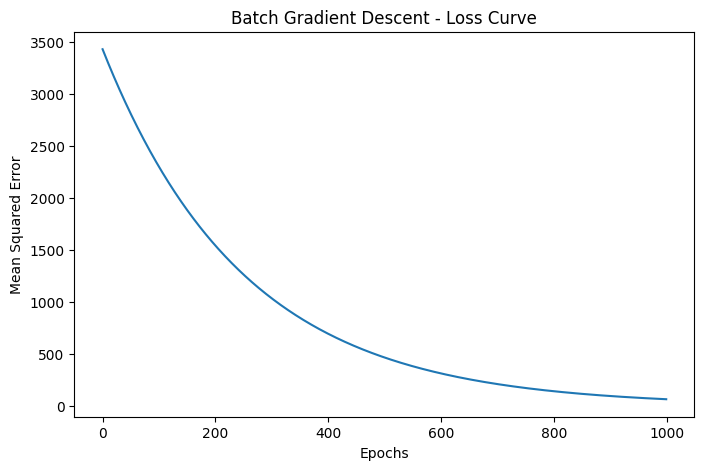

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(model.loss_history)

plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.title("Batch Gradient Descent - Loss Curve")

plt.show()

## 11. Model Evaluation

Now that the Batch Gradient Descent model has been trained, we evaluate its
performance on the **test data**.

We will use four common regression metrics:

- **MSE** → Average squared prediction error
- **RMSE** → Error in the same unit as the target
- **MAE** → Average absolute prediction error
- **R² Score** → How much variation in the target is explained by the model

$$
MSE = \frac{1}{n}\sum(y-\hat{y})^2
$$

$$
RMSE = \sqrt{MSE}
$$

$$
MAE = \frac{1}{n}\sum|y-\hat{y}|
$$

$$
R^2 = 1-\frac{SS_{res}}{SS_{tot}}
$$

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R² Score:", r2)

MSE: 65.47614069654625
RMSE: 8.091732861170483
MAE: 7.373600164289355
R² Score: 0.8233168633341814


# Gradient Descent

Gradient Descent is one of the most important **optimization algorithms in Machine Learning and Deep Learning**.

It is used to find the values of model parameters that minimize a **loss function**.

Gradient Descent is not itself a Machine Learning model.  
It is an **optimization algorithm** used to train models.

---

## 1. Why Do We Need Gradient Descent?

A machine learning model contains parameters such as:

- Weights
- Biases
- Coefficients

The model makes predictions using these parameters.

However, initially, the parameters may not be optimal, resulting in high prediction error.

Therefore, the goal of training is:

> **Find the parameter values that minimize the loss function.**

For example:

$$
Loss = f(w_1,w_2,w_3,\dots,b)
$$

where:

- $w_1,w_2,w_3$ are model weights
- $b$ is the bias
- $Loss$ measures how wrong the model predictions are

Gradient Descent provides a systematic way to update these parameters until the loss becomes as small as possible.

---

# 2. What is a Loss Function?

A **loss function** measures the difference between the actual output and the predicted output.

For example, in regression, Mean Squared Error (MSE) can be used:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

In classification, common loss functions include:

- Binary Cross-Entropy
- Categorical Cross-Entropy

In Deep Learning, the loss function depends on the task.

The general training process is:

$$
Input \rightarrow Model \rightarrow Prediction \rightarrow Loss
$$

Gradient Descent then uses the loss to determine how the model parameters should change.

---

# 3. What is a Gradient?

The **gradient** tells us how the loss changes with respect to each model parameter.

For a function with multiple parameters:

$$
L(w_1,w_2,\dots,w_n)
$$

the gradient is:

$$
\nabla L =
\begin{bmatrix}
\frac{\partial L}{\partial w_1}\\
\frac{\partial L}{\partial w_2}\\
\vdots\\
\frac{\partial L}{\partial w_n}
\end{bmatrix}
$$

The gradient contains the partial derivatives of the loss with respect to every parameter.

### Important Intuition

The gradient tells us:

> **Which direction increases the loss most rapidly.**

Therefore, to reduce the loss, we move in the **opposite direction of the gradient**.

This is the fundamental idea behind Gradient Descent.

---

# 4. Gradient Descent Intuition

Imagine standing on a mountain and trying to reach the lowest point.

You cannot see the entire mountain.

Instead, you look at the slope around your current position.

- Positive slope → move in the opposite direction
- Negative slope → move in the opposite direction
- Zero slope → you may have reached a minimum

Gradient Descent works in a similar way.

It repeatedly:

1. Calculates predictions
2. Calculates the loss
3. Calculates the gradient
4. Updates the parameters
5. Repeats the process

---

# 5. Gradient Descent Update Rule

The general update rule is:

$$
\theta_{new} =
\theta_{old} - \alpha \nabla L(\theta)
$$

where:

- $\theta$ = model parameters
- $\alpha$ = learning rate
- $\nabla L(\theta)$ = gradient of the loss function

For an individual parameter:

$$
w_{new} =
w_{old} -
\alpha
\frac{\partial L}{\partial w}
$$

Similarly, for the bias:

$$
b_{new} =
b_{old} -
\alpha
\frac{\partial L}{\partial b}
$$

---

# 6. Why Do We Subtract the Gradient?

The gradient points in the direction of **maximum increase in loss**.

We want to decrease the loss.

Therefore, we move in the opposite direction:

$$
-\nabla L
$$

Hence:

$$
\boxed{
\theta_{new} =
\theta_{old} -
\alpha\nabla L
}
$$

The negative sign is the reason the algorithm is called **Gradient Descent**.

---

# 7. Learning Rate

The **learning rate ($\alpha$)** controls how large each parameter update is.

$$
\theta_{new} =
\theta_{old} -
\alpha\nabla L
$$

### Small Learning Rate

Updates are small.

Advantages:

- More stable learning
- Less chance of overshooting the minimum

Disadvantage:

- Training can become very slow

### Large Learning Rate

Updates are large.

Advantages:

- Faster movement toward the minimum

Disadvantages:

- Can overshoot the minimum
- Can cause oscillation
- Can cause the loss to diverge

Therefore, choosing an appropriate learning rate is important.

---

# 8. Complete Gradient Descent Process

The general process is:

$$
\boxed{
Initialize\ Parameters
}
$$

↓

$$
Prediction
$$

↓

$$
Calculate\ Loss
$$

↓

$$
Calculate\ Gradient
$$

↓

$$
Update\ Parameters
$$

↓

$$
Repeat
$$

until the model converges or the maximum number of iterations is reached.

---

# 9. What is an Epoch?

An **epoch** represents one complete pass through the training dataset.

For Batch Gradient Descent:

- 1 epoch → the entire training dataset is used once
- 100 epochs → the entire dataset is processed 100 times

More epochs do not always mean better performance.

Too many epochs can lead to **overfitting**, especially when training neural networks.

---

# 10. Convergence

Gradient Descent is said to have **converged** when the loss stops decreasing significantly.

For example:

$$
Loss_1 > Loss_2 > Loss_3 > \dots
$$

Eventually:

$$
Loss_{t+1} \approx Loss_t
$$

At this point, further parameter updates produce very little improvement.

A common way to observe convergence is by plotting:

$$
Epochs \quad vs \quad Loss
$$

A decreasing and flattening curve generally indicates convergence.

---

# 11. Types of Gradient Descent

The major types of Gradient Descent are:

1. Batch Gradient Descent
2. Stochastic Gradient Descent
3. Mini-Batch Gradient Descent

The main difference is:

> **How much training data is used to calculate one parameter update.**

---

# 12. Batch Gradient Descent

Batch Gradient Descent uses the **entire training dataset** to calculate the gradient for every update.

Suppose the dataset contains 10,000 samples.

One update uses:

$$
10,000\ samples
$$

### Process

$$
10,000\ samples
\rightarrow
Gradient
\rightarrow
Update
$$

Then another complete pass is performed.

### Advantages

- Stable parameter updates
- Smooth convergence
- Deterministic updates
- Good for relatively small datasets

### Disadvantages

- Computationally expensive for large datasets
- Requires more memory
- Each update can be slow
- Not ideal for extremely large datasets

### Common Use

Batch Gradient Descent is useful when the dataset is small enough to fit comfortably into memory and stable optimization is preferred.

---

# 13. Stochastic Gradient Descent (SGD)

Stochastic Gradient Descent uses **one training sample at a time** to calculate the gradient and update the parameters.

For a dataset containing 10,000 samples:

$$
1\ sample
\rightarrow
Gradient
\rightarrow
Update
$$

This happens repeatedly for each sample.

### Advantages

- Faster individual updates
- Requires less memory
- Works well with very large datasets
- Updates can help escape some local minima or flat regions because of their noise

### Disadvantages

- Updates are noisy
- Loss may fluctuate
- Training can be less stable
- May keep moving around the minimum instead of settling smoothly

SGD is especially useful when datasets are too large for traditional full-batch optimization.

---

# 14. Mini-Batch Gradient Descent

Mini-Batch Gradient Descent combines ideas from Batch Gradient Descent and SGD.

Instead of using:

- All samples, or
- One sample

we use a **small batch of samples**.

For example:

$$
Batch\ Size = 32
$$

Then:

$$
32\ samples
\rightarrow
Gradient
\rightarrow
Update
$$

The process continues until all training samples have been processed.

Common batch sizes include:

$$
16,\ 32,\ 64,\ 128,\ 256
$$

### Advantages

- Faster than pure Batch Gradient Descent
- More stable than pure SGD
- Efficient GPU utilization
- Requires less memory than full-batch training
- Works extremely well for Deep Learning

### Disadvantages

- Batch size must be selected
- Still contains some noise in updates
- Performance can depend on batch size

---

# 15. Comparison of Gradient Descent Types

| Type | Samples per Update | Speed per Update | Stability | Memory |
|------|---------------------|------------------|-----------|--------|
| Batch GD | Entire dataset | Slow | High | High |
| SGD | 1 | Fast | Low | Very Low |
| Mini-Batch GD | Small batch | Fast | Medium/High | Medium |

### Simple Intuition

```text
Batch GD
All Data → Gradient → Update

SGD
1 Sample → Gradient → Update
1 Sample → Gradient → Update
1 Sample → Gradient → Update

Mini-Batch GD
Small Batch → Gradient → Update
Small Batch → Gradient → Update
Small Batch → Gradient → Update